# Exploratory Data Analysis: Climate Adaptation Funding and Climate Vulnerability

This notebook performs an initial exploratory data analysis of the merged country-year
panel produced in `01_clean.ipynb` (`data/processed/panel.csv`). The objective is to
characterize the structure and quality of the data, summarize the key variables, and
surface preliminary patterns in how climate-adaptation aid relates to climate
vulnerability — establishing a baseline for the modeling work in `02_model.ipynb`.

The panel covers OECD-tagged climate-adaptation aid recipients over 2010–2023, joined to
ND-GAIN vulnerability and composite scores, World Bank GDP per capita, governance, and
income classification, and binary flags for landlocked and small-island states.

In [5]:
%pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 85.7 MB/s  0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 22.1 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [seaborn]m5/7 [matplotlib]

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

PROCESSED = Path("../data/processed")
panel = pd.read_csv(PROCESSED / "panel.csv")

# --- Structure ---
print(f"Shape: {panel.shape[0]} rows x {panel.shape[1]} columns")
print(f"Countries: {panel['iso3'].nunique()}   Years: {panel['year'].min()}–{panel['year'].max()}\n")
print("Column types:")
print(panel.dtypes, "\n")

# --- Missingness ---
miss = pd.DataFrame({
    "missing": panel.isna().sum(),
    "pct": (panel.isna().mean() * 100).round(1)
})
print("Missing values by column:")
print(miss[miss["missing"] > 0].sort_values("missing", ascending=False), "\n")

panel.head()

Matplotlib is building the font cache; this may take a moment.


Shape: 1883 rows x 11 columns
Countries: 143   Years: 2010–2023

Column types:
iso3                        str
country                     str
year                      int64
adaptation_aid_usd_m    float64
vulnerability           float64
gain_score              float64
gdp_per_capita_usd      float64
gov_effectiveness       float64
income_group                str
is_landlocked             int64
is_sids                   int64
dtype: object 

Missing values by column:
                    missing  pct
gdp_per_capita_usd       54  2.9
vulnerability            45  2.4
gain_score               45  2.4
income_group             19  1.0
gov_effectiveness        14  0.7 



,iso3,country,year,adaptation_aid_usd_m,vulnerability,gain_score,gdp_per_capita_usd,gov_effectiveness,income_group,is_landlocked,is_sids
0,AFG,Afghanistan,2010,59.470952,0.583800,31.893603,560.621505,20.507295,L,1,0
1,AFG,Afghanistan,2011,129.225633,0.590539,31.075993,606.694676,20.145782,L,1,0
2,AFG,Afghanistan,2012,157.054749,0.584483,32.144508,651.417134,22.178464,L,1,0
3,AFG,Afghanistan,2013,88.860020,0.589310,31.984845,637.087099,22.155125,L,1,0
4,AFG,Afghanistan,2014,93.733749,0.587004,32.918922,625.054942,21.696063,L,1,0


## Data Structure and Completeness

The panel contains **1,883 country-year observations** spanning **143 recipient countries**
over **2010–2023**, with eleven columns: two identifiers (`iso3`, `country`), the year, the
dependent variable (`adaptation_aid_usd_m`), five predictors (`vulnerability`, `gain_score`,
`gdp_per_capita_usd`, `gov_effectiveness`, `income_group`), and two binary geographic flags
(`is_landlocked`, `is_sids`).

The identifiers, year, adaptation-aid value, and both flags are fully populated. Missingness
is confined to the merged-in predictors and is modest in every case:

| Variable | Missing | % |
|---|---|---|
| `gdp_per_capita_usd` | 54 | 2.9% |
| `vulnerability` | 45 | 2.4% |
| `gain_score` | 45 | 2.4% |
| `income_group` | 19 | 1.0% |
| `gov_effectiveness` | 14 | 0.7% |

Because the panel is anchored on the OECD adaptation-aid recipients, every row has an aid
value; the gaps arise only where a recipient lacks a matching ND-GAIN, World Bank, or income
record for a given year. The union of rows missing one or more modeling predictors is
examined in the next section and is the basis for the listwise-deletion decision carried into
`02_model.ipynb`.

In [ ]:
## Data Quality and Consistency

This section assesses the integrity of the panel: duplicate records, the structure of the
missingness, value-range plausibility, and the consistency of the categorical fields. The aim
is to confirm the data is sound for analysis and to document the one preparation step
(listwise deletion) carried into the modeling stage.

In [7]:
# --- Duplicate records ---
print("Full-row duplicates:        ", panel.duplicated().sum())
print("Duplicate (iso3, year) keys:", panel.duplicated(["iso3", "year"]).sum())

# --- Panel balance ---
n_c, n_y = panel["iso3"].nunique(), panel["year"].nunique()
print(f"\nPanel balance: {len(panel)} of {n_c*n_y} possible country-years "
      f"({n_c} countries x {n_y} years) -> {n_c*n_y - len(panel)} absent")

# --- Combined missing-predictor footprint (listwise-deletion preview) ---
model_preds = ["vulnerability", "gain_score", "gdp_per_capita_usd",
               "gov_effectiveness", "income_group"]
any_missing = panel[model_preds].isna().any(axis=1)
print(f"\nRows missing >=1 modeling predictor: {any_missing.sum()} "
      f"({any_missing.mean()*100:.1f}%)  ->  complete rows: {(~any_missing).sum()}")
print("\nCountries most affected by missingness:")
print(panel.loc[any_missing, "country"].value_counts().head(10).to_string())

# --- Value-range plausibility ---
print("\nValue ranges:")
for c in ["adaptation_aid_usd_m", "vulnerability", "gain_score",
          "gdp_per_capita_usd", "gov_effectiveness"]:
    print(f"  {c:22s} min={panel[c].min():>10.4f}   max={panel[c].max():>10.2f}")
print(f"\nZero/negative aid rows (log-safety): {(panel['adaptation_aid_usd_m'] <= 0).sum()}")

# --- Categorical consistency ---
print("\nincome_group (raw codes):")
print(panel["income_group"].value_counts(dropna=False).to_string())
chg = panel.dropna(subset=["income_group"]).groupby("iso3")["income_group"].nunique()
print(f"\nCountries reclassified across years (income_group changes): {(chg > 1).sum()}")

Full-row duplicates:         0
Duplicate (iso3, year) keys: 0

Panel balance: 1883 of 2002 possible country-years (143 countries x 14 years) -> 119 absent

Rows missing >=1 modeling predictor: 82 (4.4%)  ->  complete rows: 1801

Countries most affected by missingness:
country
Palestine, State of                       14
Kosovo                                    14
South Sudan                               13
Eritrea                                   12
Korea, Democratic People's Republic of    11
Nauru                                      5
Yemen                                      5
Saint Kitts and Nevis                      4
Cuba                                       3
Syrian Arab Republic                       1

Value ranges:
  adaptation_aid_usd_m   min=    0.0003   max=   2582.85
  vulnerability          min=    0.3073   max=      0.66
  gain_score             min=   25.6643   max=     62.52
  gdp_per_capita_usd     min=  216.7277   max=  23570.18
  gov_effectiveness      min= 

In [8]:
# Map World Bank income codes to readable, ordered labels for tables and charts.
# Original `income_group` codes are retained; `income_label` is additive.
INCOME_LABELS = {"L": "Low", "LM": "Lower-middle", "UM": "Upper-middle", "H": "High"}
INCOME_ORDER = ["Low", "Lower-middle", "Upper-middle", "High"]

panel["income_label"] = pd.Categorical(
    panel["income_group"].map(INCOME_LABELS),
    categories=INCOME_ORDER, ordered=True
)
print(panel["income_label"].value_counts().reindex(INCOME_ORDER).to_string())

income_label
Low             417
Lower-middle    709
Upper-middle    681
High             57


### Findings

**Duplicates and keys.** The panel contains no full-row duplicates and no repeated
`(iso3, year)` keys, confirming that each row is a unique country-year observation and the
merge introduced no fan-out.

**Panel balance.** The panel holds 1,883 of a possible 2,002 country-year cells
(143 countries × 14 years), leaving 119 absent. This is structural rather than an error:
because the panel is anchored on OECD adaptation-aid recipients, a country appears only in
the years it received climate-adaptation–tagged aid, so the panel is intentionally
unbalanced.

**Missingness is informative.** Of 1,883 rows, 82 (4.4%) are missing at least one modeling
predictor, and these gaps are heavily concentrated in fragile, contested, or
coverage-limited territories — Palestine (14), Kosovo (14), South Sudan (13), Eritrea (12),
and the Democratic People's Republic of Korea (11), with smaller counts for Yemen, Cuba,
Syria, and several small island states. The missingness is therefore systematic, not random:
it reflects where international index coverage is weakest. Listwise deletion is the chosen
remedy, with the understanding that it modestly underrepresents the most fragile contexts.
Of the 82 affected rows, five belong to Nauru and reflect a leading income-classification
gap (2010–2014) that `02_model.ipynb` backfills within-country; the remaining 77 are dropped,
yielding the modeling sample of 1,806.

**Value ranges are plausible.** All variables fall within expected bounds — vulnerability
spans 0.31–0.66 on its 0–1 scale, the ND-GAIN composite 25.7–62.5 and governance 7.7–76.3 on
their 0–100 scales, and GDP per capita ranges from roughly \$217 to \$23,570. Adaptation aid
is strictly positive (minimum ≈ \$0.0003M, with no zero or negative values), so the
log transform applied in later analysis is well-defined.

**Categorical consistency.** The recipient sample is concentrated in middle-income countries —
Lower-middle (709) and Upper-middle (681) dominate, followed by Low (417) and a small High
group (57), with 19 rows unclassified. The presence of high-income recipients foreshadows the
income- and eligibility-related confounding examined in the modeling stage. Income
classification is time-varying: 57 countries change group over 2010–2023, reflecting genuine
World Bank reclassification as economies develop, so income enters the analysis as a
time-varying covariate rather than a fixed national attribute.

## Descriptive Statistics

Summary statistics for the five continuous variables characterize their central tendency,
dispersion, and shape. Skewness is reported because it determines whether a variable enters later analysis on its natural scale or after a log transform.

In [9]:
cont = ["adaptation_aid_usd_m", "vulnerability", "gain_score",
        "gdp_per_capita_usd", "gov_effectiveness"]

desc = pd.DataFrame({
    "n":      panel[cont].count(),
    "mean":   panel[cont].mean(),
    "median": panel[cont].median(),
    "std":    panel[cont].std(),
    "min":    panel[cont].min(),
    "q25":    panel[cont].quantile(.25),
    "q75":    panel[cont].quantile(.75),
    "max":    panel[cont].max(),
    "skew":   panel[cont].skew(),
}).round(2)

display(desc)

# Effect of the log transform on the two right-skewed variables
print("Skewness before -> after log transform:")
print(f"  adaptation_aid_usd_m:  {panel['adaptation_aid_usd_m'].skew():.2f} "
      f"-> {np.log(panel['adaptation_aid_usd_m']).skew():.2f}")
print(f"  gdp_per_capita_usd:    {panel['gdp_per_capita_usd'].skew():.2f} "
      f"-> {np.log(panel['gdp_per_capita_usd'].dropna()).skew():.2f}")

,n,mean,median,std,min,q25,q75,max,skew
adaptation_aid_usd_m,1883,91.93,29.63,172.48,0.00,5.11,106.95,2582.85,5.40
vulnerability,1838,0.47,0.47,0.08,0.31,0.40,0.54,0.66,0.19
gain_score,1838,43.92,43.44,7.15,25.66,38.52,49.30,62.52,0.02
gdp_per_capita_usd,1829,4469.36,3466.57,3888.89,216.73,1352.17,6344.78,23570.18,1.35
gov_effectiveness,1869,42.56,42.41,12.35,7.74,34.71,51.02,76.30,-0.11


Skewness before -> after log transform:
  adaptation_aid_usd_m:  5.40 -> -0.97
  gdp_per_capita_usd:    1.35 -> -0.29


### Findings

| Variable | Mean | Median | SD | Min | Max | Skew |
|---|---|---|---|---|---|---|
| Adaptation aid (USD M) | 91.93 | 29.63 | 172.48 | 0.00 | 2,582.85 | 5.40 |
| Vulnerability (0–1) | 0.47 | 0.47 | 0.08 | 0.31 | 0.66 | 0.19 |
| ND-GAIN composite (0–100) | 43.92 | 43.44 | 7.15 | 25.66 | 62.52 | 0.02 |
| GDP per capita (USD) | 4,469 | 3,467 | 3,889 | 217 | 23,570 | 1.35 |
| Government effectiveness (0–100) | 42.56 | 42.41 | 12.35 | 7.74 | 76.30 | -0.11 |

**The need and governance measures are well-behaved.** Vulnerability, the ND-GAIN composite,
and government effectiveness are each close to symmetric (skew ≈ 0) and tightly bounded, with
mean and median nearly identical. These variables enter subsequent analysis on their natural
scales without transformation.

**Aid and income are strongly right-skewed.** Adaptation aid is the most skewed variable in
the panel (skew 5.40): its mean of \$91.9M sits well above its median of \$29.6M, its standard
deviation (\$172.5M) exceeds its mean, and the maximum (\$2,583M) is nearly ninety times the
median. A small number of very large commitments therefore dominate the distribution. GDP per
capita is moderately right-skewed (skew 1.35), as expected for an income measure.

**Log transformation is justified.** Applying a natural log reduces the skew of aid from 5.40
to −0.97 and of GDP per capita from 1.35 to −0.29, in both cases producing a far more
symmetric, near-normal distribution. This supports the log specification of aid and GDP used
in the modeling stage, where it also stabilizes variance and linearizes the aid–income
relationship.

**Dispersion previews concentration.** The extreme spread of raw aid — an interquartile range
of roughly \$5M to \$107M against a maximum above \$2.5B — signals that adaptation funding is
highly concentrated among a few recipients, a pattern examined directly in the next section.

## Frequency Distributions: Categorical Variables

The panel contains three categorical or binary descriptors — income group and the landlocked and small-island flags. Their distributions establish the composition of the recipient sample and motivate the income and geographic controls used later.

In [10]:
INCOME_ORDER = ["Low", "Lower-middle", "Upper-middle", "High"]

# Income group (country-year rows)
ic = panel["income_label"].value_counts().reindex(INCOME_ORDER)
icp = (ic / ic.sum() * 100).round(1)
print("Income group (country-year rows):")
for k in INCOME_ORDER:
    print(f"  {k:14s} {ic[k]:5d}  ({icp[k]:.1f}%)")

# Geographic flags: rows and distinct countries
for flag, label in [("is_landlocked", "Landlocked"), ("is_sids", "SIDS")]:
    print(f"\n{label}: {int(panel[flag].sum())} rows "
          f"({panel[flag].mean()*100:.1f}%), "
          f"{panel.loc[panel[flag]==1, 'iso3'].nunique()} distinct countries")

neither = ((panel["is_landlocked"] == 0) & (panel["is_sids"] == 0)).sum()
print(f"\nNeither landlocked nor SIDS: {neither} rows")

Income group (country-year rows):
  Low              417  (22.4%)
  Lower-middle     709  (38.0%)
  Upper-middle     681  (36.5%)
  High              57  (3.1%)

Landlocked: 427 rows (22.7%), 31 distinct countries

SIDS: 428 rows (22.7%), 35 distinct countries

Neither landlocked nor SIDS: 1028 rows


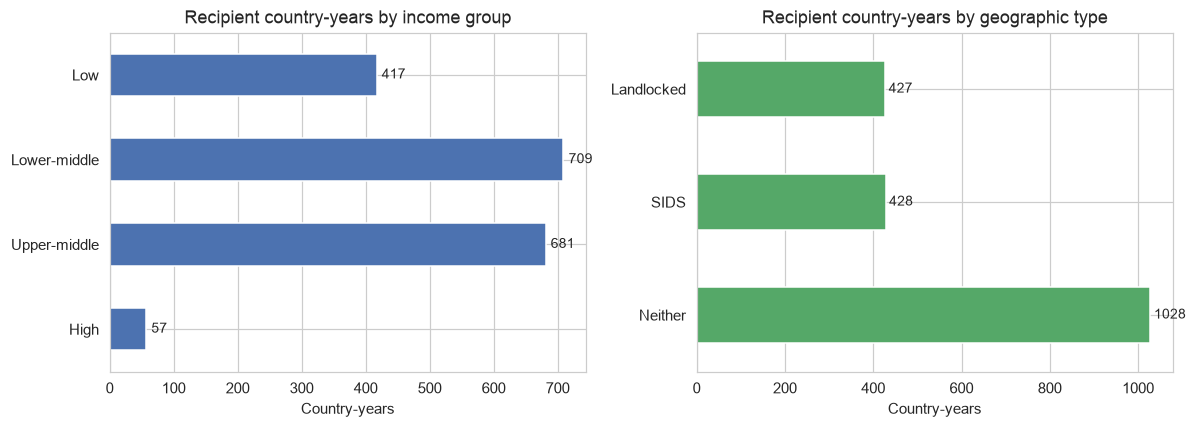

In [11]:
from pathlib import Path
FIGDIR = Path("../figures"); FIGDIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: income group
ic.plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Recipient country-years by income group")
axes[0].set_xlabel("Country-years"); axes[0].set_ylabel("")
axes[0].invert_yaxis()
for i, v in enumerate(ic):
    axes[0].text(v + 8, i, f"{v}", va="center", fontsize=9)

# Right: geography
geo = pd.Series({"Landlocked": int(panel["is_landlocked"].sum()),
                 "SIDS": int(panel["is_sids"].sum()),
                 "Neither": neither})
geo.plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("Recipient country-years by geographic type")
axes[1].set_xlabel("Country-years"); axes[1].set_ylabel("")
axes[1].invert_yaxis()
for i, v in enumerate(geo):
    axes[1].text(v + 8, i, f"{v}", va="center", fontsize=9)

plt.tight_layout()
fig.savefig(FIGDIR / "fig_categorical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### Findings

**The recipient sample skews middle-income.** Lower-middle (38.0%) and upper-middle (36.5%)
income country-years together account for roughly three-quarters of the classified sample.
Low-income country-years make up 22.4%, while high-income recipients are rare at just 3.1%
(57 country-years). This middle-income concentration is the single most important compositional
feature of the data: it signals that raw aid volume is likely to track income and aid
eligibility, and it motivates both the income control in the regression and the later decision
to restrict the analysis universe. (Because 57 countries are reclassified over the period,
country-level membership overlaps across income groups; the figures above are therefore
reported at the country-year level.)

**Vulnerable geographies are well represented.** Landlocked and small-island states each
account for about 22.7% of country-years (427 and 428 rows respectively). At the country level,
31 of the 32 UN landlocked developing countries and 35 of the 39 small island developing states
appear as adaptation-aid recipients, confirming that these especially climate-exposed groups
are broadly covered. The two flags are mutually exclusive and together span 45% of the panel;
the remaining 1,028 country-years (55%) are neither.

## Aid Distribution and Concentration

The descriptive statistics flagged adaptation aid as highly skewed. This section visualizes
that shape directly and quantifies how concentrated funding is across recipient countries —
a question central to whether aid is reaching a broad set of vulnerable nations or pooling in
a few.

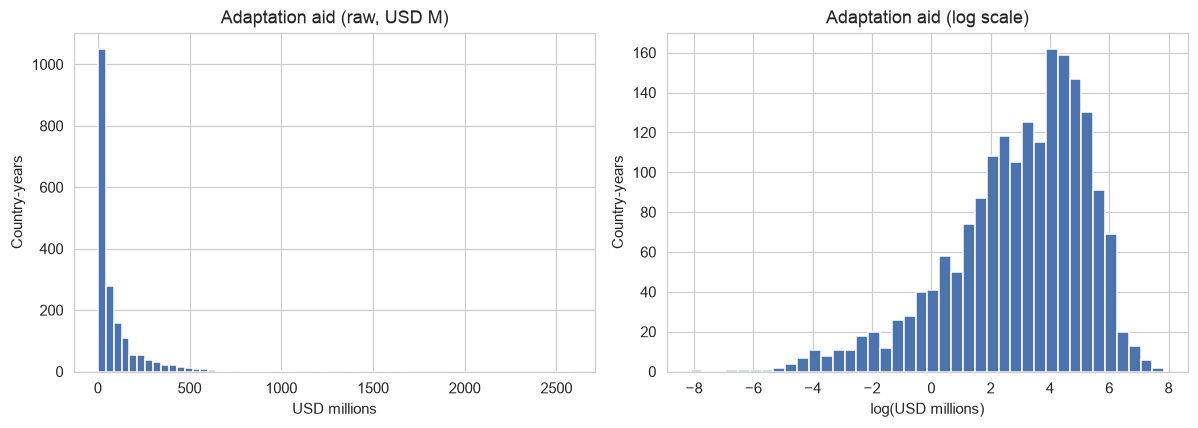

Country-years with aid < $10M:  33.5%
Country-years with aid < $50M:  58.4%
Country-years with aid > $500M: 2.4%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(panel["adaptation_aid_usd_m"], bins=60, color="#4C72B0")
axes[0].set_title("Adaptation aid (raw, USD M)")
axes[0].set_xlabel("USD millions"); axes[0].set_ylabel("Country-years")

axes[1].hist(np.log(panel["adaptation_aid_usd_m"]), bins=40, color="#4C72B0")
axes[1].set_title("Adaptation aid (log scale)")
axes[1].set_xlabel("log(USD millions)"); axes[1].set_ylabel("Country-years")

plt.tight_layout()
fig.savefig(FIGDIR / "fig_aid_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Country-years with aid < $10M:  {(panel['adaptation_aid_usd_m']<10).mean()*100:.1f}%")
print(f"Country-years with aid < $50M:  {(panel['adaptation_aid_usd_m']<50).mean()*100:.1f}%")
print(f"Country-years with aid > $500M: {(panel['adaptation_aid_usd_m']>500).mean()*100:.1f}%")

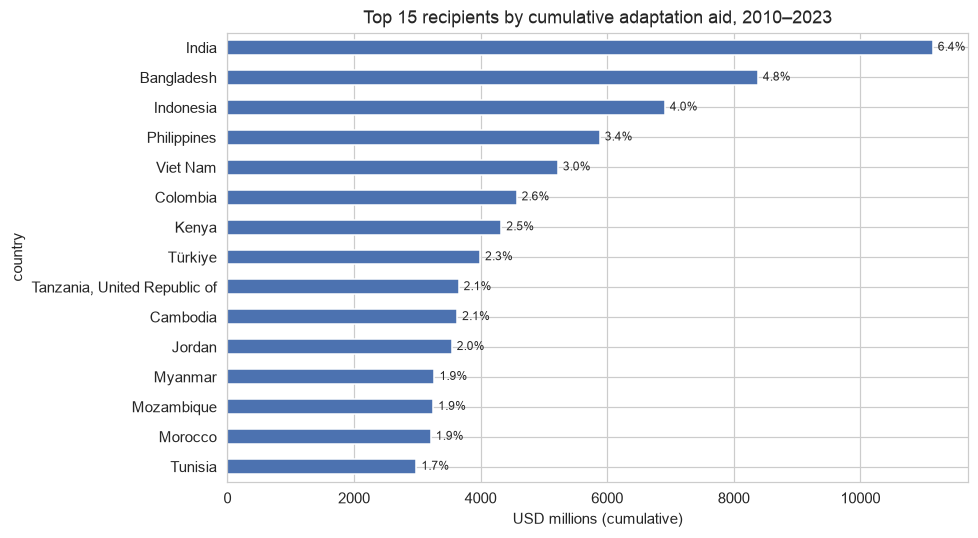

Total cumulative aid: $173,095M
  Top  5: 21.7% of all aid
  Top 10: 33.3% of all aid
  Top 20: 50.3% of all aid
  Top 30: 63.0% of all aid
Gini across 143 recipients: 0.617


In [13]:
by_c = panel.groupby("country")["adaptation_aid_usd_m"].sum().sort_values(ascending=False)
tot = by_c.sum()

def gini(x):
    x = np.sort(np.asarray(x, float)); n = len(x)
    return (2 * np.sum(np.arange(1, n+1) * x) / (n * x.sum())) - (n + 1) / n

top15 = by_c.head(15)
fig, ax = plt.subplots(figsize=(9, 5))
top15[::-1].plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Top 15 recipients by cumulative adaptation aid, 2010–2023")
ax.set_xlabel("USD millions (cumulative)")
for i, v in enumerate(top15[::-1]):
    ax.text(v + 80, i, f"{v/tot*100:.1f}%", va="center", fontsize=8)
plt.tight_layout()
fig.savefig(FIGDIR / "fig_top_recipients.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total cumulative aid: ${tot:,.0f}M")
for k in [5, 10, 20, 30]:
    print(f"  Top {k:>2}: {by_c.head(k).sum()/tot*100:.1f}% of all aid")
print(f"Gini across {len(by_c)} recipients: {gini(by_c.values):.3f}")

### Findings

**The distribution is severely right-skewed.** Raw adaptation aid clusters near zero with a
long thin tail: 33.5% of country-years receive under \$10M and 58.4% under \$50M, while only
2.4% exceed \$500M. On a log scale the distribution becomes approximately symmetric and
bell-shaped, confirming that log(aid) is the appropriate scale for modeling — consistent with
the reduction in skewness reported in the descriptive statistics.

**Funding is highly concentrated.** Cumulative adaptation commitments over 2010–2023 total
roughly \$173 billion, but they are unevenly distributed across the 143 recipients: the top 5
countries absorb 21.7% of all aid, the top 10 a third (33.3%), and the top 20 fully half
(50.3%). A Gini coefficient of 0.617 confirms a high degree of inequality in how funding is
spread.

**The largest recipients are large and middle-income, not the most vulnerable.** The biggest
beneficiaries are populous, mostly middle-income economies — India (6.4% of all aid),
Bangladesh, Indonesia, the Philippines, and Viet Nam, alongside middle-income states such as
Colombia, Türkiye, Jordan, Morocco, and Tunisia. Few are among the most climate-vulnerable
countries by ND-GAIN. This is the first direct evidence that aid volume tracks country size
and income more closely than climate vulnerability, the question examined explicitly in the
next section and the motivation for the size and income controls introduced in the modeling
stage.

## The Central Relationship: Vulnerability and Aid

The project's core question is whether adaptation funding tracks climate vulnerability. This section examines that relationship directly — its strength, its direction, and whether it changed after the 2015 Paris Agreement.

n = 1838
vulnerability vs log(aid):  Pearson r = 0.123  (Spearman 0.124), R^2 = 0.015
vulnerability vs raw aid:    Pearson r = 0.037
ND-GAIN composite vs log(aid): Pearson r = -0.173

Pre-2015  (n=791):  r = 0.117
Post-2015 (n=1047): r = 0.150


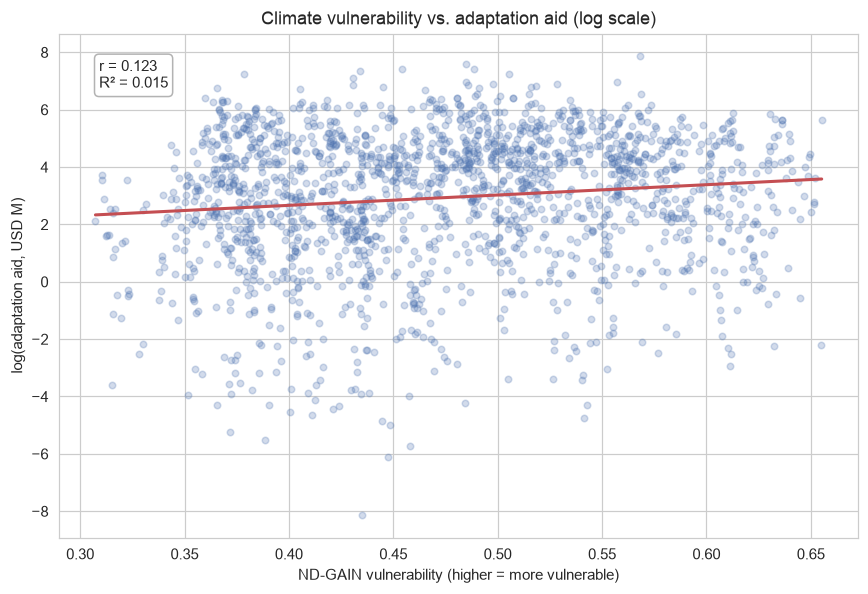

In [14]:
d = panel.dropna(subset=["vulnerability", "adaptation_aid_usd_m"]).copy()
d = d[d["adaptation_aid_usd_m"] > 0]
d["log_aid"] = np.log(d["adaptation_aid_usd_m"])

r_all = d["vulnerability"].corr(d["log_aid"])
print(f"n = {len(d)}")
print(f"vulnerability vs log(aid):  Pearson r = {r_all:.3f}  "
      f"(Spearman {d['vulnerability'].corr(d['log_aid'], method='spearman'):.3f}), "
      f"R^2 = {r_all**2:.3f}")
print(f"vulnerability vs raw aid:    Pearson r = {d['vulnerability'].corr(d['adaptation_aid_usd_m']):.3f}")
print(f"ND-GAIN composite vs log(aid): Pearson r = {d['gain_score'].corr(d['log_aid']):.3f}")

pre, post = d[d["year"] <= 2015], d[d["year"] > 2015]
print(f"\nPre-2015  (n={len(pre)}):  r = {pre['vulnerability'].corr(pre['log_aid']):.3f}")
print(f"Post-2015 (n={len(post)}): r = {post['vulnerability'].corr(post['log_aid']):.3f}")

# Scatter with fitted line
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(d["vulnerability"], d["log_aid"], alpha=0.25, s=18, color="#4C72B0")
b = np.polyfit(d["vulnerability"], d["log_aid"], 1)
xs = np.linspace(d["vulnerability"].min(), d["vulnerability"].max(), 100)
ax.plot(xs, np.polyval(b, xs), color="#C44E52", lw=2)
ax.set_title("Climate vulnerability vs. adaptation aid (log scale)")
ax.set_xlabel("ND-GAIN vulnerability (higher = more vulnerable)")
ax.set_ylabel("log(adaptation aid, USD M)")
ax.text(0.05, 0.95, f"r = {r_all:.3f}\nR² = {r_all**2:.3f}",
        transform=ax.transAxes, va="top",
        bbox=dict(boxstyle="round", fc="white", ec="0.7"))
plt.tight_layout()
fig.savefig(FIGDIR / "fig_vulnerability_vs_aid.png", dpi=150, bbox_inches="tight")
plt.show()

### Findings

**The raw relationship is weak.** The correlation between climate vulnerability and adaptation
aid is positive but very weak: Pearson r = 0.123 against log(aid) and only 0.037 against raw
aid. The Spearman coefficient (0.124) is nearly identical, so the result is not an artifact of
a few outliers. On its own, vulnerability explains roughly 1.5% of the variation in (log) aid
(R² = 0.015). The direction is as one would hope — more vulnerable countries receive slightly
more — but the magnitude is negligible. At the bivariate level, a country's climate
vulnerability is a poor predictor of how much adaptation funding it receives. The ND-GAIN
composite, which is higher for better-prepared countries, correlates negatively with aid
(r = −0.173), consistent with the same weak pattern.

**The Paris Agreement did not strengthen the link.** Splitting the panel at 2015, the
vulnerability–aid correlation is essentially flat — 0.117 before the Paris Agreement and 0.150
after. There is no evidence that the agreement was followed by a meaningful tightening of the
relationship between climate need and adaptation funding, supporting the project's hypothesis
that allocation patterns have not realigned toward vulnerability over time.

**The puzzle, not yet the answer.** A weak raw correlation is consistent with two very
different explanations: either funding genuinely disregards vulnerability, or the vulnerability
signal is masked by structural factors — country size, income, and aid eligibility — that
drive aid volume independently. The concentration analysis already showed that the largest
recipients are large, middle-income economies, which points toward the second explanation. The
modeling stage disentangles these influences by introducing size and income controls; the role
of this exploratory analysis is to establish the puzzle, not to resolve it.

## Structural Patterns: Income, Region, and Predictor Collinearity

The weak raw vulnerability–aid link raises the question of what *does* structure funding. This
section examines how aid and vulnerability vary across income groups and world regions, and
maps the correlations among the candidate predictors — both to expose the confounding that
masks the vulnerability signal and to surface the multicollinearity that shapes the modeling
specification.

In [15]:
# ISO3 -> region (UN subregions collapsed to a 6-region World Bank-style scheme;
# a few transcontinental recipients reassigned to match World Bank convention).
REGION_MAP = {"AFG":"South Asia","AGO":"Sub-Saharan Africa","ALB":"Europe & Central Asia","ARG":"Latin America & Caribbean","ARM":"Europe & Central Asia","ATG":"Latin America & Caribbean","AZE":"Europe & Central Asia","BDI":"Sub-Saharan Africa","BEN":"Sub-Saharan Africa","BFA":"Sub-Saharan Africa","BGD":"South Asia","BIH":"Europe & Central Asia","BLR":"Europe & Central Asia","BLZ":"Latin America & Caribbean","BOL":"Latin America & Caribbean","BRA":"Latin America & Caribbean","BRB":"Latin America & Caribbean","BTN":"South Asia","BWA":"Sub-Saharan Africa","CAF":"Sub-Saharan Africa","CHL":"Latin America & Caribbean","CHN":"East Asia & Pacific","CIV":"Sub-Saharan Africa","CMR":"Sub-Saharan Africa","COD":"Sub-Saharan Africa","COG":"Sub-Saharan Africa","COL":"Latin America & Caribbean","COM":"Sub-Saharan Africa","CPV":"Sub-Saharan Africa","CRI":"Latin America & Caribbean","CUB":"Latin America & Caribbean","DJI":"Sub-Saharan Africa","DMA":"Latin America & Caribbean","DOM":"Latin America & Caribbean","DZA":"Middle East & North Africa","ECU":"Latin America & Caribbean","EGY":"Middle East & North Africa","ERI":"Sub-Saharan Africa","FJI":"East Asia & Pacific","FSM":"East Asia & Pacific","GAB":"Sub-Saharan Africa","GEO":"Europe & Central Asia","GHA":"Sub-Saharan Africa","GIN":"Sub-Saharan Africa","GMB":"Sub-Saharan Africa","GNB":"Sub-Saharan Africa","GNQ":"Sub-Saharan Africa","GRD":"Latin America & Caribbean","GTM":"Latin America & Caribbean","GUY":"Latin America & Caribbean","HND":"Latin America & Caribbean","HRV":"Europe & Central Asia","HTI":"Latin America & Caribbean","IDN":"East Asia & Pacific","IND":"South Asia","IRN":"South Asia","IRQ":"Middle East & North Africa","JAM":"Latin America & Caribbean","JOR":"Middle East & North Africa","KAZ":"Europe & Central Asia","KEN":"Sub-Saharan Africa","KGZ":"Europe & Central Asia","KHM":"East Asia & Pacific","KIR":"East Asia & Pacific","KNA":"Latin America & Caribbean","LAO":"East Asia & Pacific","LBN":"Middle East & North Africa","LBR":"Sub-Saharan Africa","LBY":"Middle East & North Africa","LCA":"Latin America & Caribbean","LKA":"South Asia","LSO":"Sub-Saharan Africa","MAR":"Middle East & North Africa","MDA":"Europe & Central Asia","MDG":"Sub-Saharan Africa","MDV":"South Asia","MEX":"Latin America & Caribbean","MHL":"East Asia & Pacific","MKD":"Europe & Central Asia","MLI":"Sub-Saharan Africa","MMR":"East Asia & Pacific","MNE":"Europe & Central Asia","MNG":"East Asia & Pacific","MOZ":"Sub-Saharan Africa","MRT":"Sub-Saharan Africa","MUS":"Sub-Saharan Africa","MWI":"Sub-Saharan Africa","MYS":"East Asia & Pacific","NAM":"Sub-Saharan Africa","NER":"Sub-Saharan Africa","NGA":"Sub-Saharan Africa","NIC":"Latin America & Caribbean","NPL":"South Asia","NRU":"East Asia & Pacific","OMN":"Middle East & North Africa","PAK":"South Asia","PAN":"Latin America & Caribbean","PER":"Latin America & Caribbean","PHL":"East Asia & Pacific","PLW":"East Asia & Pacific","PNG":"East Asia & Pacific","PRK":"East Asia & Pacific","PRY":"Latin America & Caribbean","PSE":"Middle East & North Africa","RWA":"Sub-Saharan Africa","SDN":"Middle East & North Africa","SEN":"Sub-Saharan Africa","SLB":"East Asia & Pacific","SLE":"Sub-Saharan Africa","SLV":"Latin America & Caribbean","SOM":"Sub-Saharan Africa","SRB":"Europe & Central Asia","SSD":"Sub-Saharan Africa","STP":"Sub-Saharan Africa","SUR":"Latin America & Caribbean","SWZ":"Sub-Saharan Africa","SYC":"Sub-Saharan Africa","SYR":"Middle East & North Africa","TCD":"Sub-Saharan Africa","TGO":"Sub-Saharan Africa","THA":"East Asia & Pacific","TJK":"Europe & Central Asia","TKM":"Europe & Central Asia","TLS":"East Asia & Pacific","TON":"East Asia & Pacific","TTO":"Latin America & Caribbean","TUN":"Middle East & North Africa","TUR":"Europe & Central Asia","TUV":"East Asia & Pacific","TZA":"Sub-Saharan Africa","UGA":"Sub-Saharan Africa","UKR":"Europe & Central Asia","URY":"Latin America & Caribbean","UZB":"Europe & Central Asia","VCT":"Latin America & Caribbean","VNM":"East Asia & Pacific","VUT":"East Asia & Pacific","WSM":"East Asia & Pacific","XKV":"Europe & Central Asia","YEM":"Middle East & North Africa","ZAF":"Sub-Saharan Africa","ZMB":"Sub-Saharan Africa","ZWE":"Sub-Saharan Africa"}

panel["region"] = panel["iso3"].map(REGION_MAP)
print(panel["region"].value_counts().to_string())

region
Sub-Saharan Africa            644
Latin America & Caribbean     374
East Asia & Pacific           329
Europe & Central Asia         249
Middle East & North Africa    165
South Asia                    122


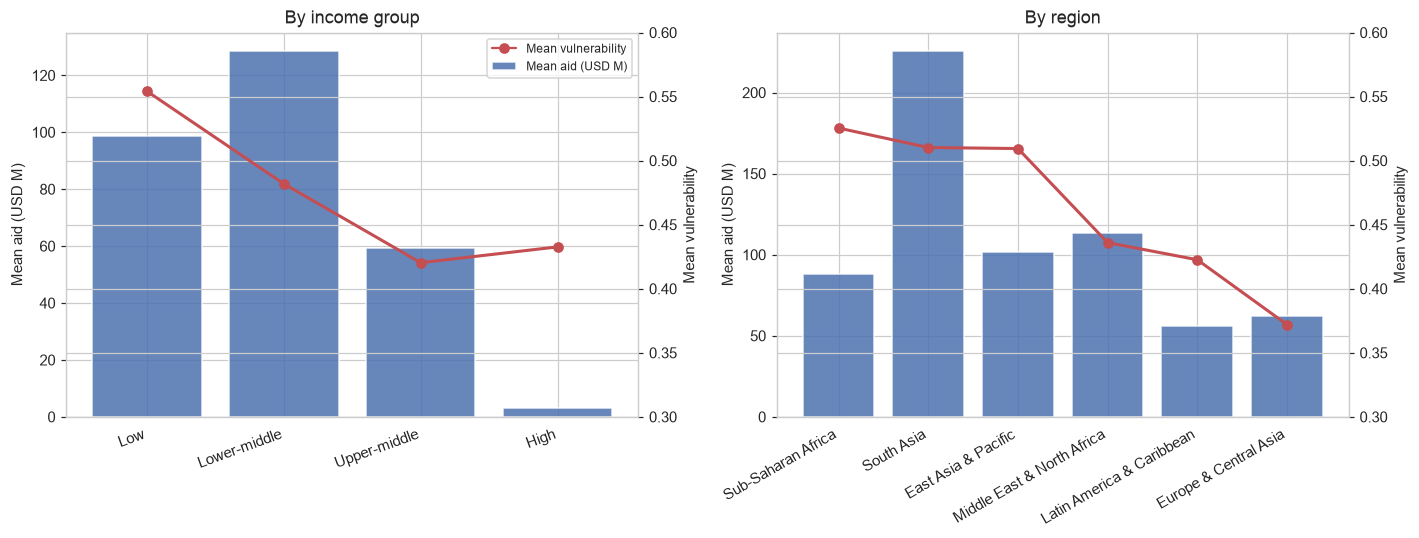

In [16]:
inc_ord = ["Low", "Lower-middle", "Upper-middle", "High"]
gi = panel.groupby("income_label").agg(mean_aid=("adaptation_aid_usd_m", "mean"),
                                       mean_vuln=("vulnerability", "mean")).reindex(inc_ord)
gr = panel.groupby("region").agg(mean_aid=("adaptation_aid_usd_m", "mean"),
                                 mean_vuln=("vulnerability", "mean")).sort_values("mean_vuln", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, g, title, rot in [(axes[0], gi, "By income group", 20), (axes[1], gr, "By region", 30)]:
    x = range(len(g))
    ax.bar(x, g["mean_aid"], color="#4C72B0", alpha=0.85, label="Mean aid (USD M)")
    ax.set_xticks(list(x)); ax.set_xticklabels(g.index, rotation=rot, ha="right")
    ax.set_ylabel("Mean aid (USD M)"); ax.set_title(title)
    ax2 = ax.twinx()
    ax2.plot(x, g["mean_vuln"], color="#C44E52", marker="o", lw=2, label="Mean vulnerability")
    ax2.set_ylabel("Mean vulnerability"); ax2.set_ylim(0.3, 0.6)

axes[0].plot([], [], color="#C44E52", marker="o", label="Mean vulnerability")  # legend proxy
axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout()
fig.savefig(FIGDIR / "fig_structural_income_region.png", dpi=150, bbox_inches="tight")
plt.show()

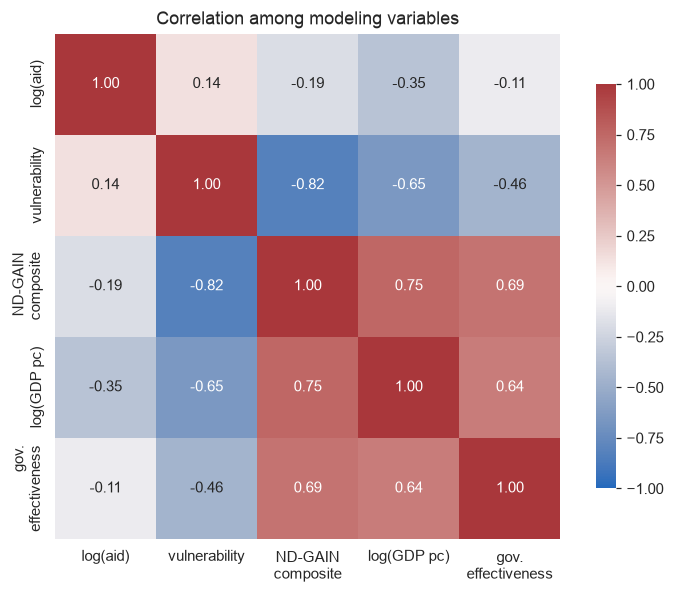

In [17]:
d = panel.dropna(subset=["vulnerability", "gain_score", "gdp_per_capita_usd",
                         "gov_effectiveness", "adaptation_aid_usd_m"]).copy()
d = d[d["adaptation_aid_usd_m"] > 0]
d["log_aid"] = np.log(d["adaptation_aid_usd_m"])
d["log_gdp"] = np.log(d["gdp_per_capita_usd"])

order = ["log_aid", "vulnerability", "gain_score", "log_gdp", "gov_effectiveness"]
labels = ["log(aid)", "vulnerability", "ND-GAIN\ncomposite", "log(GDP pc)", "gov.\neffectiveness"]
cm = d[order].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1,
            square=True, xticklabels=labels, yticklabels=labels,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation among modeling variables")
plt.tight_layout()
fig.savefig(FIGDIR / "fig_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Findings

**Aid tracks an income "sweet spot," not need.** Vulnerability declines steadily as income
rises — from 0.55 in low-income country-years to 0.42 in upper-middle ones — but mean aid does
not follow the same path. It peaks at the *lower-middle*-income tier (\$129M per country-year),
exceeding the more vulnerable low-income tier (\$99M), while upper-middle countries still draw
\$59M. Funding gravitates toward aid-eligible middle-income recipients rather than toward the
most vulnerable, the clearest single illustration of the income confound.

**The most vulnerable region is not the best funded.** Sub-Saharan Africa is the most
vulnerable region (mean 0.53) and has the most recipients (47 countries) and the largest total
allocation (\$56.8B), yet its mean aid per country-year (\$88M) trails South Asia (\$226M) and
East Asia & Pacific (\$102M). South Asia — only nine countries, dominated by India, Bangladesh,
and Pakistan — commands by far the highest mean aid, reinforcing that funding follows large,
populous economies. Even Europe & Central Asia, the least vulnerable region (0.37), averages
\$62M.

**Vulnerability is entangled with poverty, governance, and a near-duplicate index.** The
correlation heatmap shows that vulnerability and the ND-GAIN composite are almost mirror images
(r = −0.82), confirming the multicollinearity that justifies excluding the composite from the
regression. Vulnerability is also strongly associated with low income (r = −0.65 with log GDP)
and weak governance (r = −0.46): the most climate-vulnerable countries are also the poorest and
least institutionally capable. Because those same factors independently influence how much aid
a country receives, the simple vulnerability–aid correlation is confounded. Isolating the
effect of vulnerability therefore requires holding income, governance, and country size
constant — precisely the role of the multivariate model in the next stage of the project.